# News Folha SP

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('FolhaSP/articles.csv')
print(df.shape)

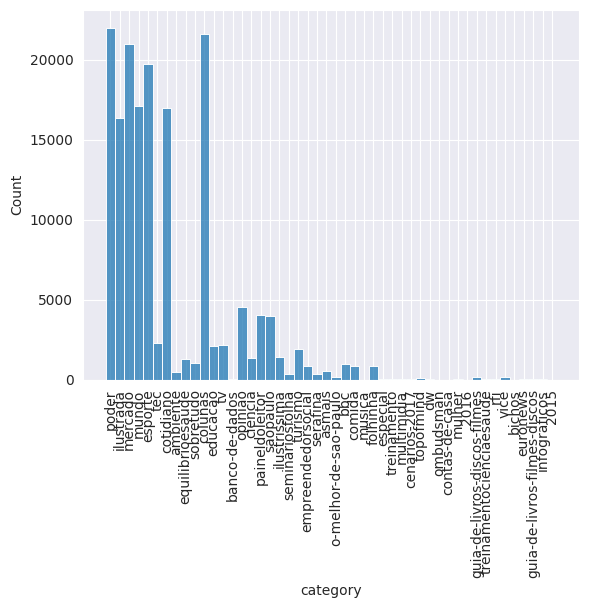

In [4]:
sns.histplot(df['category'])
plt.xticks(rotation=90)
plt.show()

In [5]:
topic_count = df['category'].value_counts()

categories = [x for x in df['category'].unique() if topic_count[x] > 1000]
df_filtered = df[df['category'].isin(categories)].copy()

In [6]:
df_filtered.dropna(subset=['category'], inplace=True)
df_filtered.dropna(subset=['text'], inplace=True)

In [8]:
print(len(df_filtered['category'].unique()))
print(df_filtered.shape)

18

In [33]:
df_filtered.to_csv('FolhaSP/articles_filtered.csv')

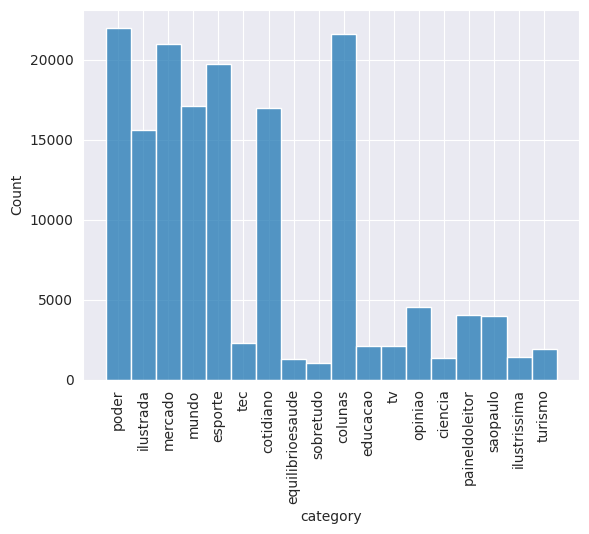

In [34]:
sns.histplot(df_filtered['category'])
plt.xticks(rotation=90)
plt.show()

# ITALIC

10


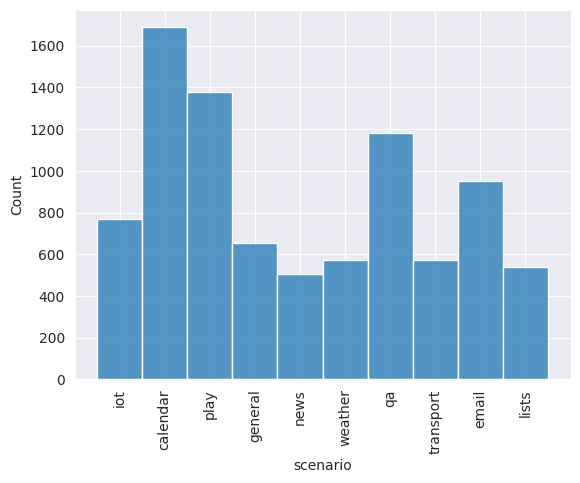

10


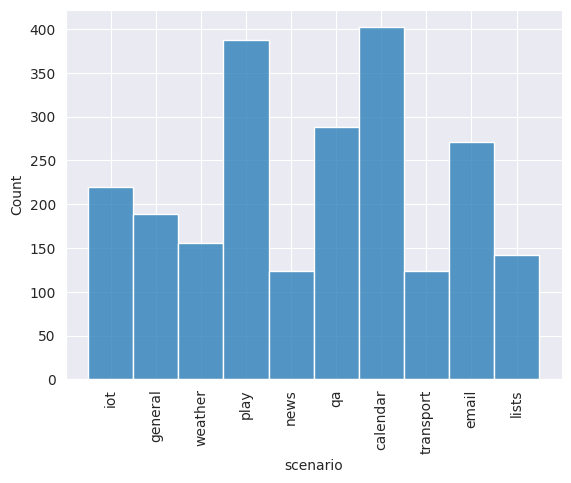

In [49]:
scenarios = None
for split in ['train', 'test']:
    df = pd.read_json(f'italic/massive_{split}.json', lines=True)
    scenario_count = df['scenario'].value_counts()
    if scenarios is None:
        scenarios = [x for x in df['scenario'].unique() if scenario_count[x] > 500]
    df_filtered = df[df['scenario'].isin(scenarios)].copy()
    df_filtered.to_csv(f'italic/massive_{split}_filtered.csv')

    print(len(df_filtered['scenario'].unique()))
    sns.histplot(df_filtered['scenario'])
    plt.xticks(rotation=90)
    plt.show()

### From load_dataset (ERROR)

In [1]:
from datasets import load_dataset

italic = load_dataset("RiTA-nlp/ITALIC", "massive", use_auth_token=True)
italic_train = italic["train"]
italic_valid = italic["validation"]
italic_test  = italic["test"]

RuntimeError: Dataset scripts are no longer supported, but found ITALIC.py

# END